1. What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?
  - CNN is a specialized neural nework used to process and analyze visual data, like images and videos.
  - CNN reduces the input features using kernel filters and pooling, which ANN lacks.
  - CNN helps model to train faster and reduces trainable paramters, which saves computation.

2. Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.
  - Architecture of LeNet-5:
    - Input Layer: 32x32 pixel grayscale image.
    - C1 (Convolutional Layer): 6 feature maps, each 28x28. Each neuron is connected to a 5x5 input patch.
    - S2 (Subsampling/Pooling Layer): 6 feature maps, each 14x14. Each unit sums 2x2 input features from C1.
    - C3 (Convolutional Layer): 16 feature maps, each 10x10. Uses 16 different 5x5 kernels.
    - S4 (Subsampling/Pooling Layer): 16 feature maps, each 5x5.
    - C5 (Convolutional Layer): 120 feature maps, each 1x1.
    - F6 (Fully Connected Layer): 84 units, connecting to all 120 units in C5.
    - Output Layer: 10 units (for digits 0-9).
  - Foundation for Modern Deep Learning Models:
    - Convolutional Layers.
    - Pooling Layers.
    - End-to-End Learning.
    - Stacked Architecture.
    - Gradient Based Learning.
  - Original Research Paper:
    - LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. Proceedings of the IEEE, 86(11), 2278-2324.

3. Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.
  - Alexnet
    - Deeper Architecture: AlexNet was significantly deeper than previous networks.
    - Relu: Rectified Linear Unit was one of it's key innovation.
    - GPU parallelization: It leverages GPU for training.
    - Local Response Normalization
    - Overlapping Max Pooling: Max pooling was performed with a stride smaller than the kernel size.
    - Data Augmentation and Dropout.
  - Number of parameters: 60-62 million.
  - Performance: Achieved a top-5 error rate of 15.3% on ImageNet.
  - Key Innovations: ReLU activation, large-scale GPU training, extensive data augmentation, dropout, and significantly deeper architecture than its predecessors.
  - Limitations: Relatively large number of parameters.
  - VGGNet
    - Simplicity and Uniformity: VGGNet prioritized simplicity and uniformity in its architecture. It exclusively used very small 3x3 convolutional filters and 2x2 max pooling layers. This allowed for building very deep networks.
    - Stacked Small Filters: The idea was that stacking multiple 3x3 convolutional layers (e.g., three 3x3 convolutions) is equivalent to one larger convolutional layer (e.g., one 7x7 convolution) in terms of receptive field.
    - Increased Depth: By sticking to a simple, repetitive block design, VGG was able to go much deeper than AlexNet.
  - Number of parameters: 138-144 million.
  - Performance: Achieved a top-5 error rate of 7.3% on ImageNet.
  - Key Innovations: Emphasis on uniform architecture with small (3x3) convolutional filters, demonstrating the power of network depth. Its simplicity made it a popular choice for feature extraction in other tasks.
  - Limitations: Extremely high number of parameters, making it computationally expensive to train and requiring significant memory. Slower inference time.

4. What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.
  - Transfer learning is a technique used for training pre trained models to achieve related task.
  - In transfer learning, we take a pre trained model. So no need to train whole model. We will only train the fully connected layer. These will give us better performance even for small datasets.

5. Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?
  - A residual block consists of one or more convolutional layers and a shortcut connection that skips one or more layers and adds the output of these skipped layers directly to the output of the stacked layers.
  - Gradients can flow directly through skip paths.
  - Even if layers weaken gradients, shortcut keeps them alive.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 6. Implement the LeNet-5 architectures using Tensorflow or PyTorch to
# classify the MNIST dataset. Report the accuracy and training time.
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import time

(X_train, y_train), (X_test, y_test) = mnist.load_data() # Load dataset

# Normalize
X_train = X_train / 255.
X_test = X_test / 255.

# Resize
X_train = tf.image.resize(X_train[..., tf.newaxis], (32, 32))
X_test = tf.image.resize(X_test[..., tf.newaxis], (32, 32))

# model
model = Sequential([
    Conv2D(6, kernel_size=5, activation='tanh', input_shape=(32, 32, 1)),
    AveragePooling2D(pool_size=2),

    Conv2D(16, kernel_size=5, activation='tanh'),
    AveragePooling2D(pool_size=2),

    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

# compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# train
start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.1
)

training_time = time.time() - start_time

# evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Accuracy: {test_acc*100:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8417 - loss: 0.5806 - val_accuracy: 0.9388 - val_loss: 0.2224
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9325 - loss: 0.2276 - val_accuracy: 0.9597 - val_loss: 0.1483
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9547 - loss: 0.1542 - val_accuracy: 0.9707 - val_loss: 0.1096
Epoch 4/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9648 - loss: 0.1164 - val_accuracy: 0.9762 - val_loss: 0.0866
Epoch 5/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9728 - loss: 0.0912 - val_accuracy: 0.9787 - val_loss: 0.0794
Accuracy: 97.34%
Training Time: 11.35 seconds


In [ ]:
# 7. Use a pre-trained VGG16 model (via transfer learning) on a small custom
# dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model.
# Include your code and result discussion.
import tensorflow as tf
import tensorflow_datasets as tfds

# Load dataset
(dataset_train, dataset_val), info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = info.features['label'].num_classes

IMG_SIZE = 224
BATCH_SIZE = 64

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_data = dataset_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_data = dataset_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

loss, acc = model.evaluate(val_data)

print(f"Accuracy: {acc*100:.2f}%")

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4782 - loss: 1.3136 - val_accuracy: 0.6853 - val_loss: 0.9653
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 387ms/step - accuracy: 0.6798 - loss: 0.9057 - val_accuracy: 0.7425 - val_loss: 0.7625
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 391ms/step - accuracy: 0.7251 - loss: 0.7655 - val_accuracy: 0.7766 - val_loss: 0.6802
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 391ms/step - accuracy: 0.7653 - loss: 0.6768 - val_accuracy: 0.7888 - val_loss: 0.6101
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 386ms/step - accuracy: 0.7718 - loss: 0.6329 - val_accuracy: 0.7725 - val_loss: 0.6133
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 292ms/step - accuracy: 0.7725 - loss: 0.6133
Accuracy: 77.25%


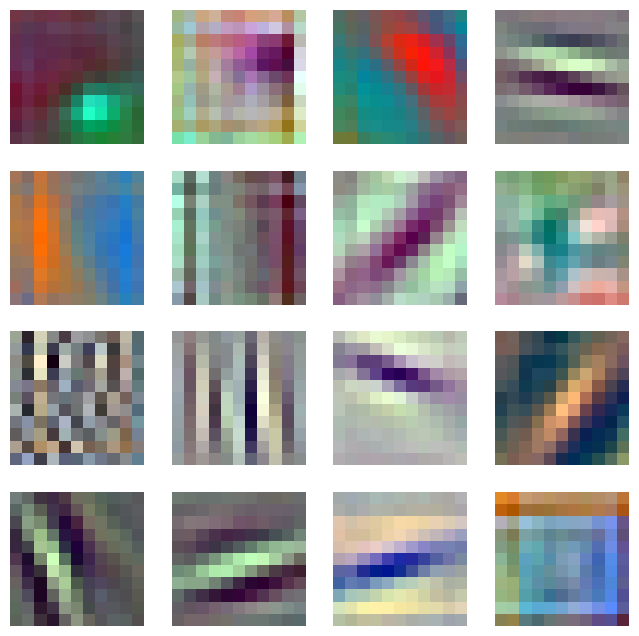

In [ ]:
# 8. Write a program to visualize the filters and feature maps of the first
# convolutional layer of AlexNet on an example input image.
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load pretrained AlexNet
model = models.alexnet(pretrained=True)
model.eval()

first_conv = model.features[0]  # Conv2d(3, 64, kernel_size=11)
filters = first_conv.weight.data.clone()

import numpy as np

# Normalize filters for visualization
def normalize(tensor):
    tensor = tensor - tensor.min()
    tensor = tensor / tensor.max()
    return tensor

# Plot first 16 filters
fig, axes = plt.subplots(4, 4, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    f = filters[i]
    f = normalize(f)
    f = f.permute(1, 2, 0)  # CHW → HWC
    ax.imshow(f)
    ax.axis('off')

plt.show()

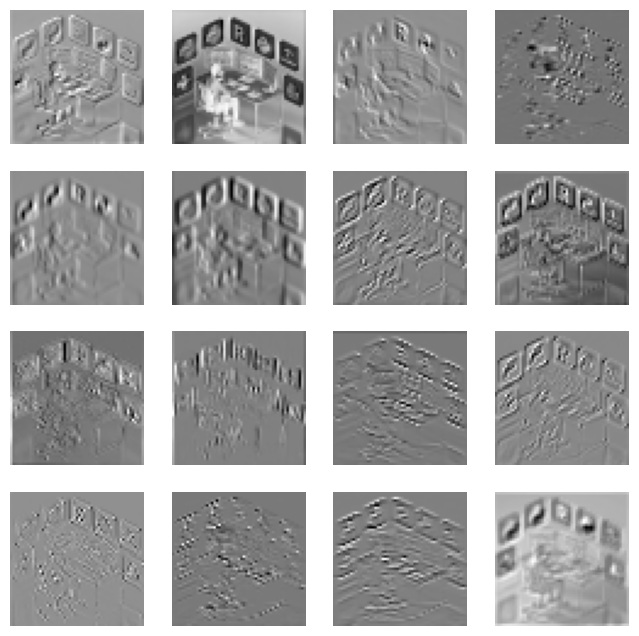

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img = Image.open("Cover image.jpeg").convert("RGB")
img_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    feature_maps = first_conv(img_tensor)

fm = feature_maps.squeeze(0)  # remove batch

fig, axes = plt.subplots(4, 4, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    ax.imshow(fm[i].cpu(), cmap='gray')
    ax.axis('off')

plt.show()

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 46.1MB/s]


Epoch 1/5: Train Acc=24.52%, Val Acc=24.90%, Time=10.3s
Epoch 2/5: Train Acc=31.60%, Val Acc=34.70%, Time=8.6s
Epoch 3/5: Train Acc=35.06%, Val Acc=36.90%, Time=8.3s
Epoch 4/5: Train Acc=39.06%, Val Acc=42.20%, Time=8.7s
Epoch 5/5: Train Acc=42.70%, Val Acc=45.80%, Time=10.7s

Total training time: 46.6 seconds


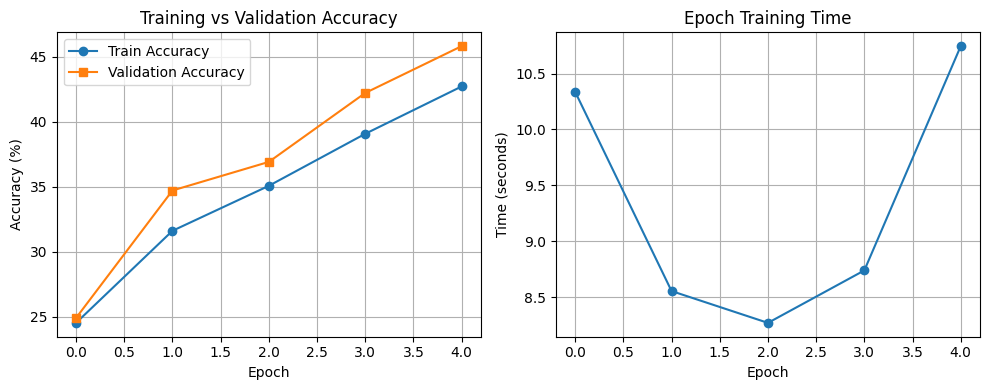


=== Analysis ===
Final Train Accuracy: 42.70%
Final Validation Accuracy: 45.80%
Train-Val Gap: -3.10%
⚠️ Possible Underfitting: Small gap but low validation accuracy
   Suggestions: Increase model complexity, train for more epochs, adjust learning rate


In [2]:
# 9. Train a GoogLeNet (Inception v1) or its variant using a standard dataset
# like CIFAR-10. Plot the training and validation accuracy over epochs and analyze
# overfitting or underfitting.
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Optimized transforms - smaller image size for faster processing
transform_train = transforms.Compose([
    transforms.Resize(64),  # Reduced from 224 to 64
    transforms.RandomHorizontalFlip(),  # Add data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize(64),  # Reduced from 224 to 64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load smaller subset for faster training
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Use smaller batch size and fewer samples for speed
train_subset = torch.utils.data.Subset(trainset, range(0, 5000))  # Use only 5000 training samples
test_subset = torch.utils.data.Subset(testset, range(0, 1000))    # Use only 1000 test samples

trainloader = torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=2)

# Use a simplified GoogLeNet variant (without aux_logits for speed)
import torchvision.models as models
import torch.nn as nn

# Use a lighter model - you can also try mobilenet_v2 for even faster training
model = models.googlenet(pretrained=False, aux_logits=False)  # Disable aux_logits for speed
model.fc = nn.Linear(1024, 10)  # CIFAR-10 classes

# Adjust the first convolution for smaller input size (64x64 instead of 224x224)
# This is optional but helps with smaller inputs
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  # Changed from 7x7 to 3x3
model.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)  # Adjust pooling

model = model.to(device)
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_acc_list = []
val_acc_list = []
epoch_times = []

epochs = 5  # Reduced epochs for faster training

start_time = time.time()

for epoch in range(epochs):
    epoch_start = time.time()
    model.train()
    correct, total = 0, 0
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # Simplified since aux_logits=False

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item()

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_list.append(val_acc)

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1}/{epochs}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%, Time={epoch_time:.1f}s")

total_time = time.time() - start_time
print(f"\nTotal training time: {total_time:.1f} seconds")

# Plotting results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label='Train Accuracy', marker='o')
plt.plot(val_acc_list, label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epoch_times, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Time (seconds)')
plt.title('Epoch Training Time')
plt.grid(True)

plt.tight_layout()
plt.show()

# Analyze overfitting/underfitting
print("\n=== Analysis ===")
final_train_acc = train_acc_list[-1]
final_val_acc = val_acc_list[-1]
gap = final_train_acc - final_val_acc

print(f"Final Train Accuracy: {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")
print(f"Train-Val Gap: {gap:.2f}%")

if gap > 15:
    print("⚠️ Possible Overfitting: Large gap between train and validation accuracy")
    print("   Suggestions: Add more data augmentation, increase dropout, reduce model complexity")
elif gap < 2:
    print("⚠️ Possible Underfitting: Small gap but low validation accuracy")
    print("   Suggestions: Increase model complexity, train for more epochs, adjust learning rate")
else:
    print("✓ Good balance: Model is generalizing well")

In [ ]:
# 10: You are working in a healthcare AI startup. Your team is tasked with
# developing a system that automatically classifies medical X-ray images into normal,
# pneumonia, and COVID-19. Due to limited labeled data, what approach would you
# suggest using among CNN architectures discussed (e.g., transfer learning with ResNet
# or Inception variants)? Justify your approach and outline a deployment strategy for
# production use.

# - CNN from scratch will overfit on small dataset.
# - So, i will use ResNet as base model.
# - Resnet has already learned edges, textures, patterns.
# - I will use data augmentation for increasing data.
# - I will only train fully connected layer for my use case.
# - This will give us a generalized model.

# Pipeline:
# Input image
# Pre processing: image size to 224*224, normalize
# Predicion

# Deployment strategy:
# - Covert to TensorFlow Lite / ONNX
# - Use FastAPI, flask, uvicorn
# - Create frontend using jinja2
# - Testing
# - Deploy